### Part1 Multi_animal_data Import and Correlation Analysis

In [ ]:
import pickle

data_directory = r"C:\Users\Pulee\Desktop\multi_animal_data_20260423_164459.pickle"
with open(data_directory, "rb") as f:
    multi_animal_data = pickle.load(f)

for animal_data in multi_animal_data:
    animal_unique_id = animal_data["animal_single_channel_id"]

### Part2 Bout_analysis_results Import and Correlation Analysis

#### Part2.1 Running

C:\Users\Pulee\AppData\Local\Temp\ipykernel_17552\1035541714.py:115: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_speeds = [np.trapz(res["speeds"], dx=1) for res in target_results]
C:\Users\Pulee\AppData\Local\Temp\ipykernel_17552\1035541714.py:116: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_dffs = [np.trapz(res["dff"], dx=1) for res in target_results]
C:\Users\Pulee\AppData\Local\Temp\ipykernel_17552\1035541714.py:117: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_zscores = [np.trapz(res["zscore"], dx=1) for res in target_results]


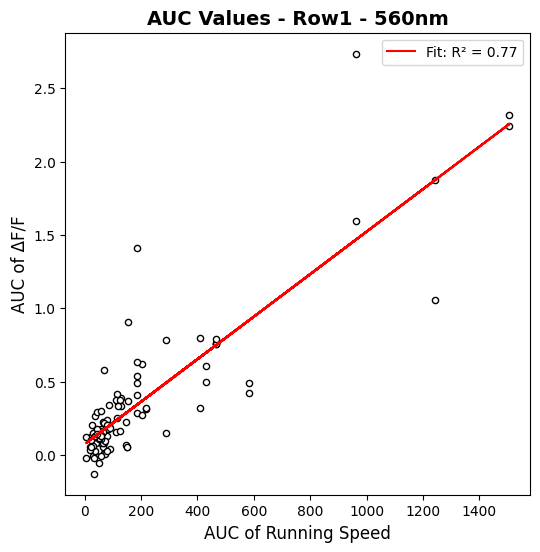

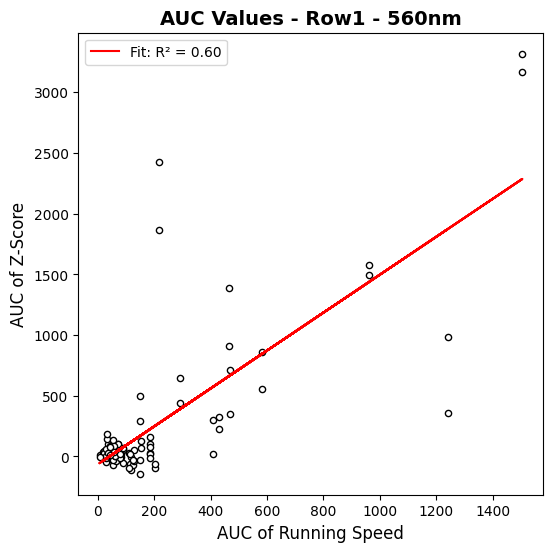

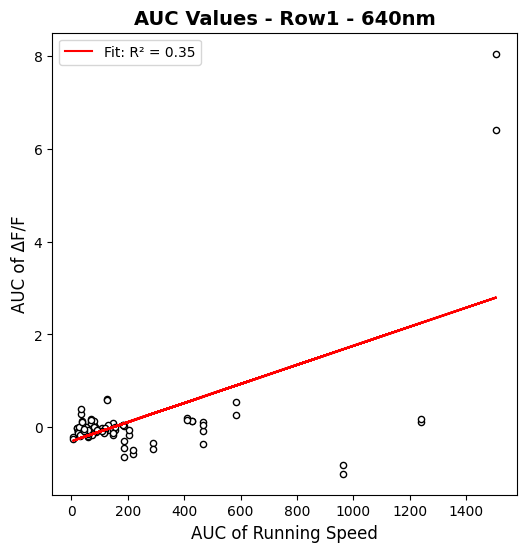

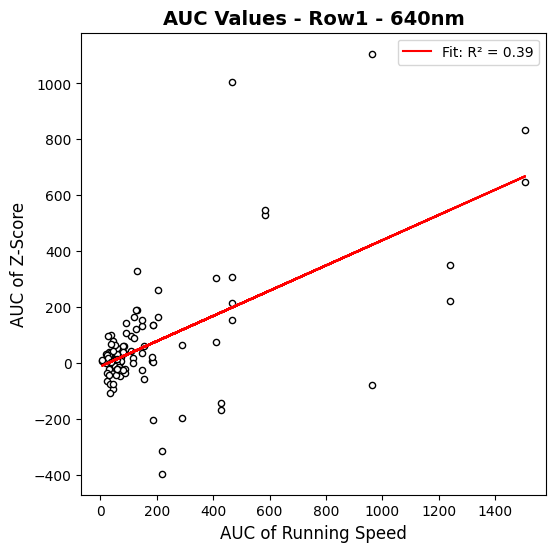

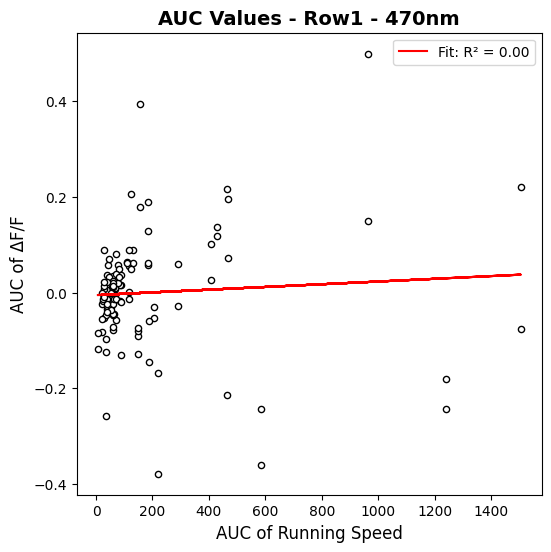

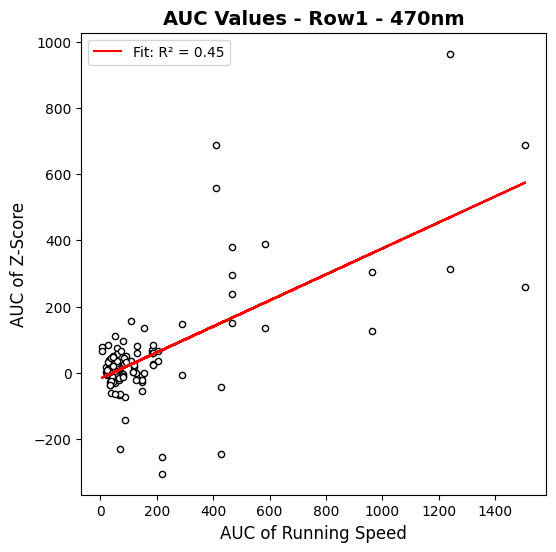

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

bout_analysis_results_directory = r"C:\Users\Pulee\Desktop\Bout analysis\running\running_only_bout_analysis_results_20260424_211003.pickle"
with open(bout_analysis_results_directory, "rb") as f:
    bout_analysis_results = pickle.load(f)
    
all_results = []
all_row_names = set()
all_wavelengths = set()
for row_name, animals in bout_analysis_results.items():
    all_row_names.add(row_name)
    for res in animals:
        bout_speeds = res["bout_speeds"]
        bout_dffs = res["bout_dffs"]
        speed_timestamps = res["speed_timestamps"]
        event_fiber_timestamps = res["fiber_timestamps"]
        # Interpolate dff to match speed timestamps
        bout_speeds_interp = np.interp(event_fiber_timestamps, speed_timestamps, bout_speeds)
        for wavelength, dff in bout_dffs.items():
            all_wavelengths.add(wavelength)
            zscore = res["bout_zscores"][wavelength]
            results = {
                "row_name": row_name,
                "wavelength": wavelength,
                "speeds": bout_speeds_interp,
                "dff": dff,
                "zscore": zscore
            }
            all_results.append(results)

for row_name in all_row_names:
    for wavelength in all_wavelengths:
        target_results = [res for res in all_results if res["row_name"] == row_name and res["wavelength"] == wavelength]
        if not target_results:
            continue
        speeds = np.concatenate([res["speeds"] for res in target_results])
        dffs = np.concatenate([res["dff"] for res in target_results])
        zscores = np.concatenate([res["zscore"] for res in target_results])
        # r_squared_dff = np.corrcoef(speeds, dffs)[0, 1] ** 2
        # fitted_line_dff = np.polyfit(speeds, dffs, 1)
        # r_squared_zscore = np.corrcoef(speeds, zscores)[0, 1] ** 2
        # fitted_line_zscore = np.polyfit(speeds, zscores, 1)
        # plt.figure(figsize=(10, 6))
        # plt.scatter(speeds, dffs, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
        # plt.plot(speeds, np.polyval(fitted_line_dff, speeds), label=f"Fit: R² = {r_squared_dff:.2f}", color='red')
        # plt.title(f"{row_name} - {wavelength}nm")
        # plt.xlabel("Running Speed (cm/s)")
        # plt.ylabel("ΔF/F")
        # plt.legend()
        # plt.show()
        
        # plt.figure(figsize=(10, 6))
        # plt.scatter(speeds, zscores, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
        # plt.plot(speeds, np.polyval(fitted_line_zscore, speeds), label=f"Fit: R² = {r_squared_zscore:.2f}", color='red')
        # plt.title(f"{row_name} - {wavelength}nm")
        # plt.xlabel("Running Speed (cm/s)")
        # plt.ylabel("Z-Score")
        # plt.legend()
        # plt.show()
        
        # peak_speeds = [np.max(res["speeds"]) for res in target_results]
        # positive_peak_dffs = [np.max(res["dff"]) for res in target_results]
        # negative_peak_dffs = [np.min(res["dff"]) for res in target_results]
        # positive_peak_zscores = [np.max(res["zscore"]) for res in target_results]
        # negative_peak_zscores = [np.min(res["zscore"]) for res in target_results]
        
        # r_squared_positive_peak_dff = np.corrcoef(peak_speeds, positive_peak_dffs)[0, 1] ** 2
        # fitted_line_positive_peak_dff = np.polyfit(peak_speeds, positive_peak_dffs, 1)
        # r_squared_positive_peak_zscore = np.corrcoef(peak_speeds, positive_peak_zscores)[0, 1] ** 2
        # fitted_line_positive_peak_zscore = np.polyfit(peak_speeds, positive_peak_zscores, 1)
        
        # r_squared_negative_peak_dff = np.corrcoef(peak_speeds, negative_peak_dffs)[0, 1] ** 2
        # fitted_line_negative_peak_dff = np.polyfit(peak_speeds, negative_peak_dffs, 1)
        # r_squared_negative_peak_zscore = np.corrcoef(peak_speeds, negative_peak_zscores)[0, 1] ** 2
        # fitted_line_negative_peak_zscore = np.polyfit(peak_speeds, negative_peak_zscores, 1)

        # plt.figure(figsize=(10, 6))
        # plt.scatter(peak_speeds, positive_peak_dffs, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
        # plt.plot(peak_speeds, np.polyval(fitted_line_positive_peak_dff, peak_speeds), label=f"Fit: R² = {r_squared_positive_peak_dff:.2f}", color='red')
        # plt.title(f"Peak Values - {row_name} - {wavelength}nm", fontweight='bold', fontsize=14)
        # plt.xlabel("Peak Running Speed (cm/s)", fontsize=12)
        # plt.ylabel("Positive Peak ΔF/F", fontsize=12)
        # plt.legend()
        # plt.show()
        
        # plt.figure(figsize=(10, 6))
        # plt.scatter(peak_speeds, positive_peak_zscores, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
        # plt.plot(peak_speeds, np.polyval(fitted_line_positive_peak_zscore, peak_speeds), label=f"Fit: R² = {r_squared_positive_peak_zscore:.2f}", color='red')
        # plt.title(f"Peak Values - {row_name} - {wavelength}nm", fontweight='bold', fontsize=14)
        # plt.xlabel("Peak Running Speed (cm/s)", fontsize=12)
        # plt.ylabel("Positive Peak Z-Score", fontsize=12)
        # plt.legend()
        # plt.show()
        
        # plt.figure(figsize=(10, 6))
        # plt.scatter(peak_speeds, negative_peak_dffs, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
        # plt.plot(peak_speeds, np.polyval(fitted_line_negative_peak_dff, peak_speeds), label=f"Fit: R² = {r_squared_negative_peak_dff:.2f}", color='red')
        # plt.title(f"Peak Values - {row_name} - {wavelength}nm", fontweight='bold', fontsize=14)
        # plt.xlabel("Peak Running Speed (cm/s)", fontsize=12)
        # plt.ylabel("Negative Peak ΔF/F", fontsize=12)
        # plt.legend()
        # plt.show()
        
        # plt.figure(figsize=(10, 6))
        # plt.scatter(peak_speeds, negative_peak_zscores, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
        # plt.plot(peak_speeds, np.polyval(fitted_line_negative_peak_zscore, peak_speeds), label=f"Fit: R² = {r_squared_negative_peak_zscore:.2f}", color='red')
        # plt.title(f"Peak Values - {row_name} - {wavelength}nm", fontweight='bold', fontsize=14)
        # plt.xlabel("Peak Running Speed (cm/s)", fontsize=12)
        # plt.ylabel("Negative Peak Z-Score", fontsize=12)
        # plt.legend()
        # plt.show()
        
        auc_speeds = [np.trapz(res["speeds"], dx=1) for res in target_results]
        auc_dffs = [np.trapz(res["dff"], dx=1) for res in target_results]
        auc_zscores = [np.trapz(res["zscore"], dx=1) for res in target_results]
        r_squared_auc_dff = np.corrcoef(auc_speeds, auc_dffs)[0, 1] ** 2
        fitted_line_auc_dff = np.polyfit(auc_speeds, auc_dffs, 1)
        r_squared_auc_zscore = np.corrcoef(auc_speeds, auc_zscores)[0, 1] ** 2
        fitted_line_auc_zscore = np.polyfit(auc_speeds, auc_zscores, 1)
        
        plt.figure(figsize=(6, 6))
        plt.scatter(auc_speeds, auc_dffs, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
        plt.plot(auc_speeds, np.polyval(fitted_line_auc_dff, auc_speeds), label=f"Fit: R² = {r_squared_auc_dff:.2f}", color='red')
        plt.title(f"AUC Values - {row_name} - {wavelength}nm", fontweight='bold', fontsize=14)
        plt.xlabel("AUC of Running Speed", fontsize=12)
        plt.ylabel("AUC of ΔF/F", fontsize=12)
        plt.legend()
        plt.show()
        
        plt.figure(figsize=(6, 6))
        plt.scatter(auc_speeds, auc_zscores, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
        plt.plot(auc_speeds, np.polyval(fitted_line_auc_zscore, auc_speeds), label=f"Fit: R² = {r_squared_auc_zscore:.2f}", color='red')
        plt.title(f"AUC Values - {row_name} - {wavelength}nm", fontweight='bold', fontsize=14)
        plt.xlabel("AUC of Running Speed", fontsize=12)
        plt.ylabel("AUC of Z-Score", fontsize=12)
        plt.legend()
        plt.show()

#### Part2.2 Running+Drug

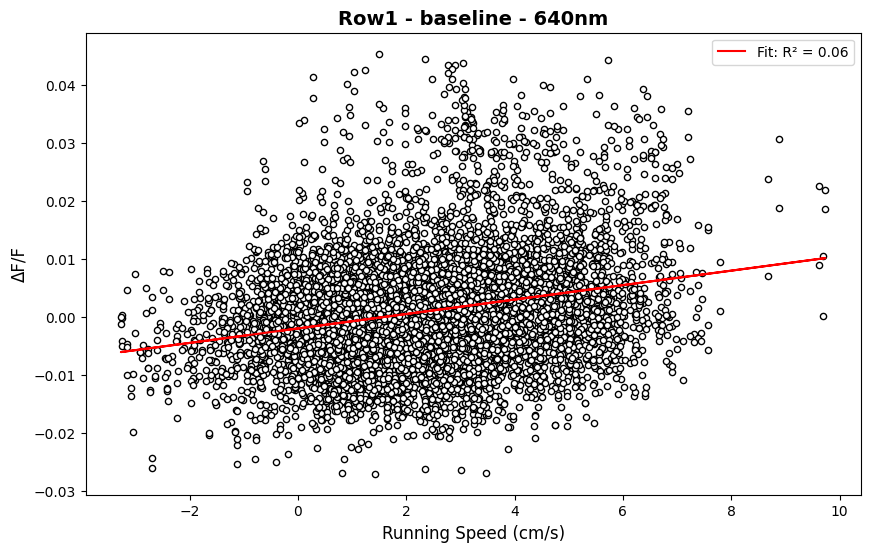

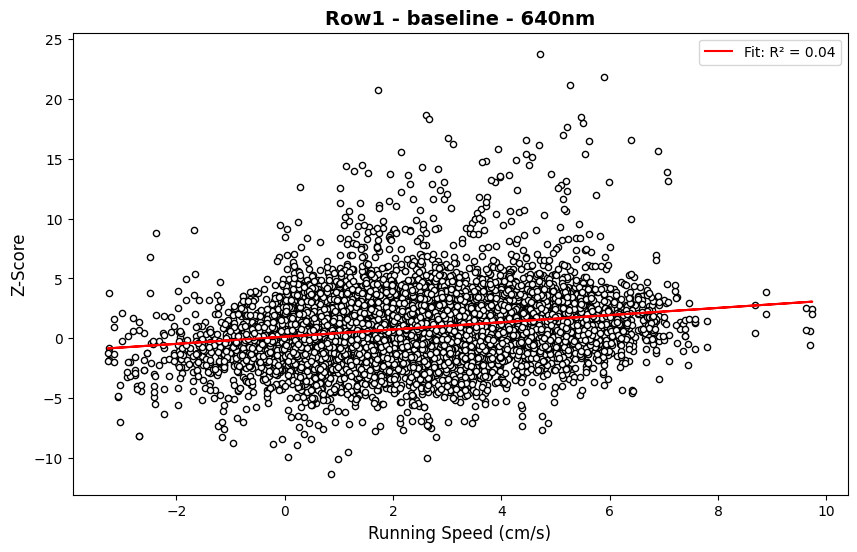

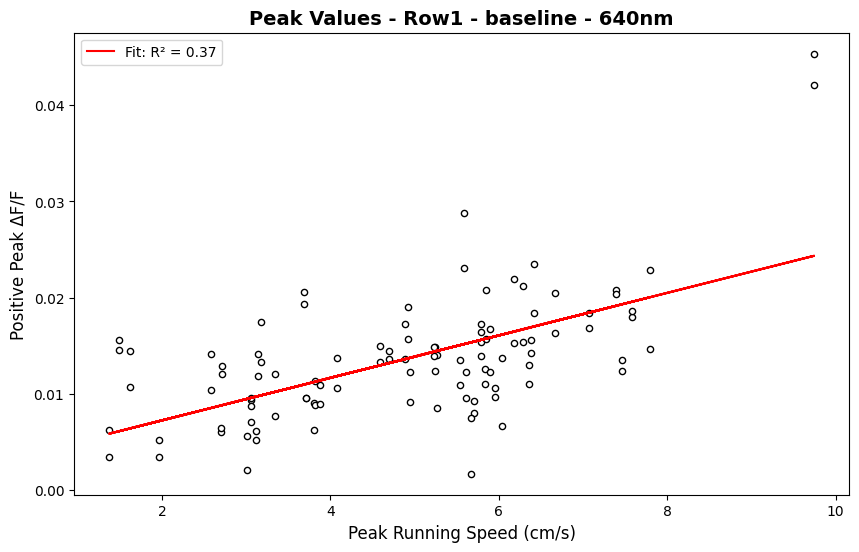

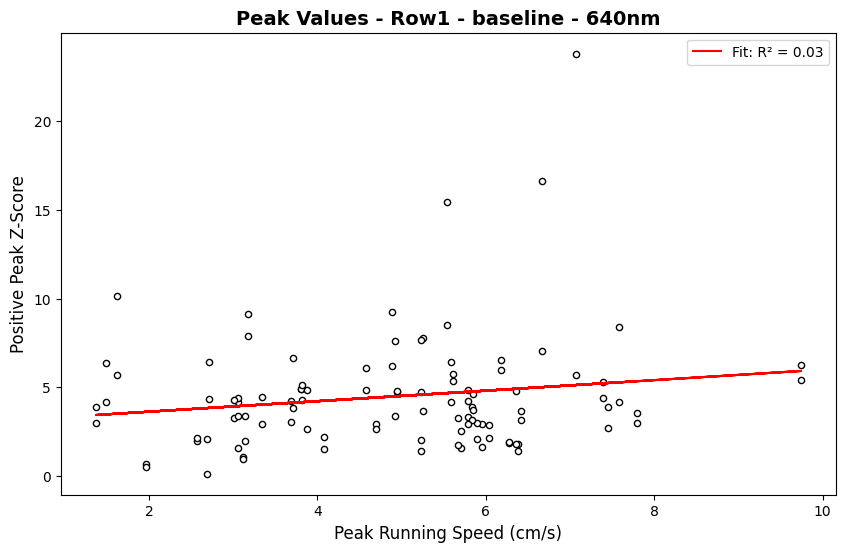

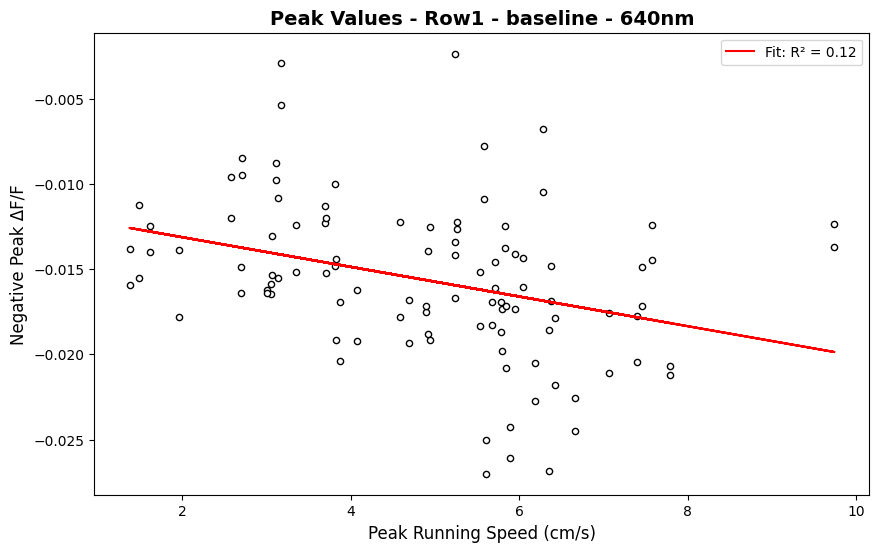

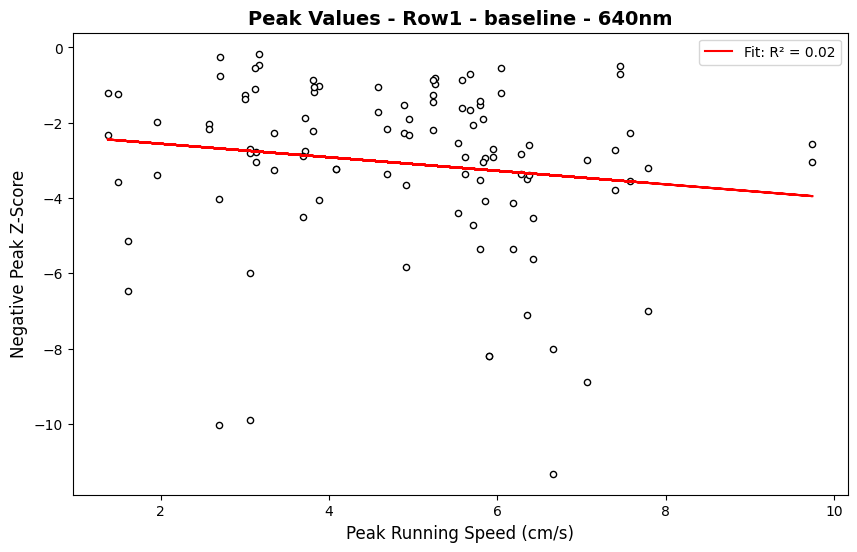

C:\Users\Pulee\AppData\Local\Temp\ipykernel_20796\2263504354.py:120: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_speeds = [np.trapz(res["speeds"], dx=1) for res in target_results]
C:\Users\Pulee\AppData\Local\Temp\ipykernel_20796\2263504354.py:121: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_dffs = [np.trapz(res["dff"], dx=1) for res in target_results]
C:\Users\Pulee\AppData\Local\Temp\ipykernel_20796\2263504354.py:122: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_zscores = [np.trapz(res["zscore"], dx=1) for res in target_results]


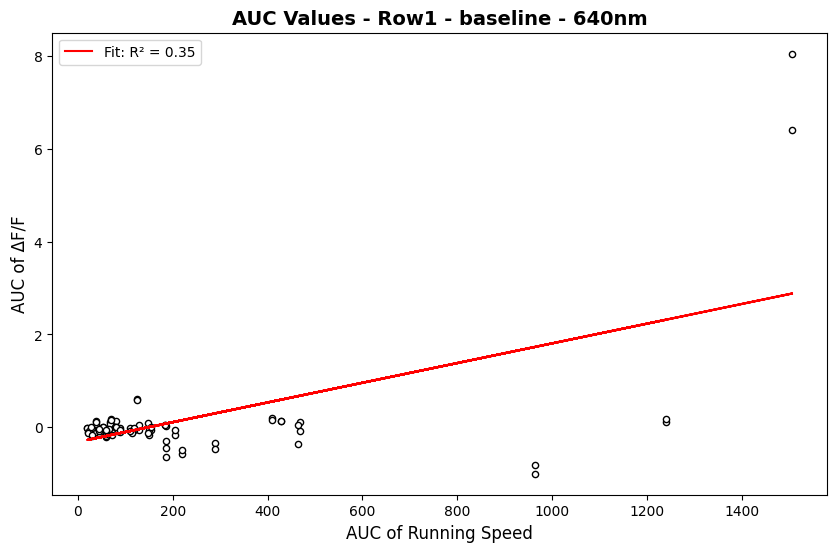

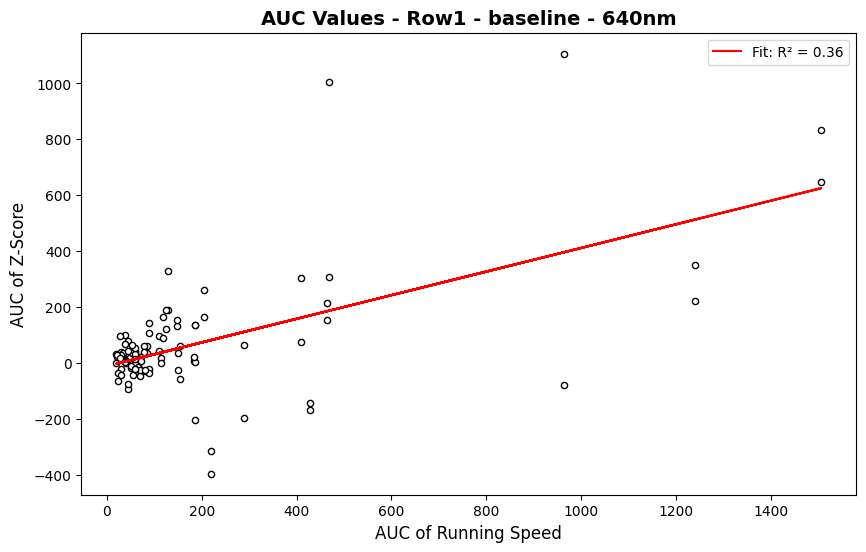

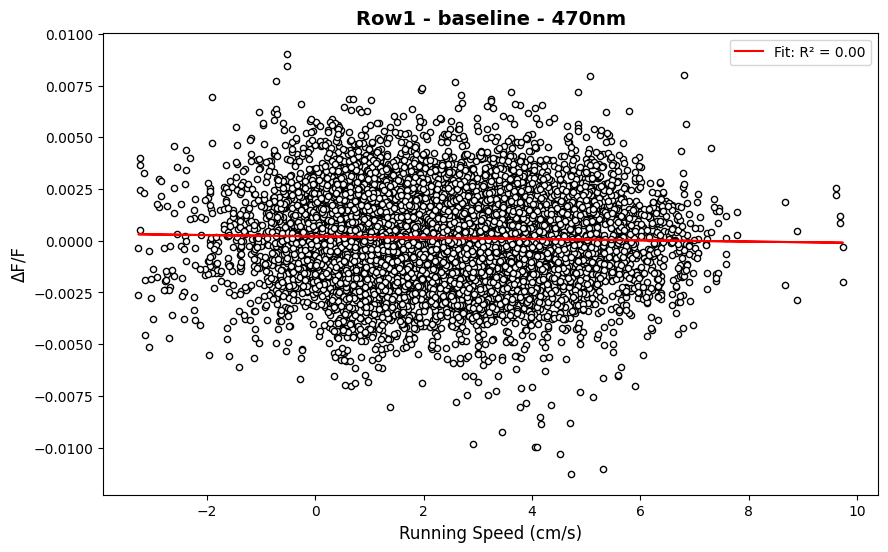

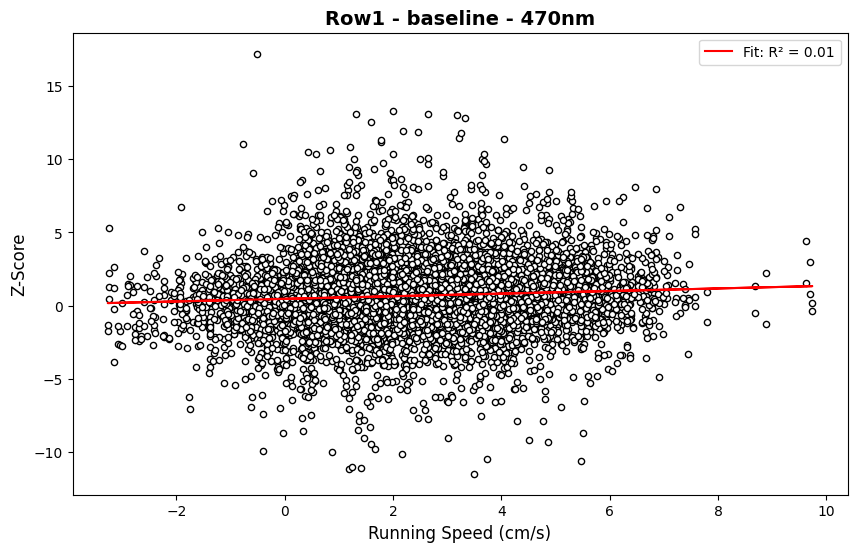

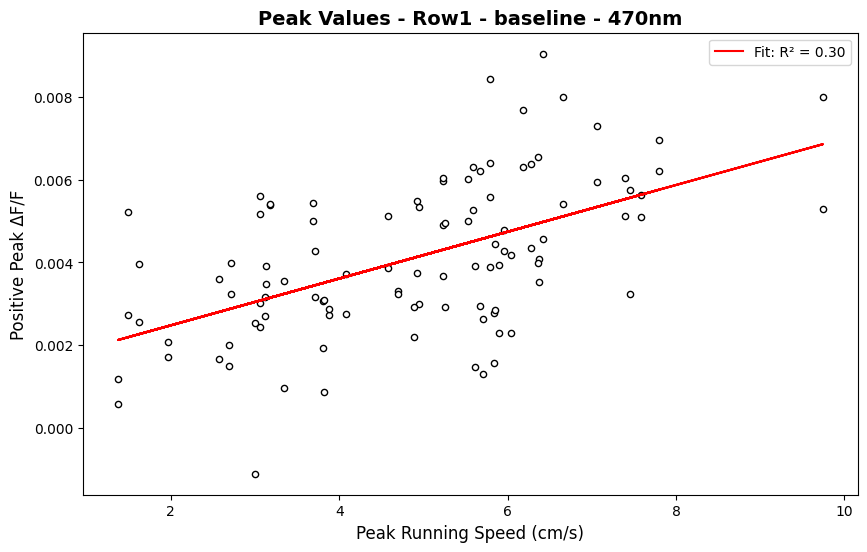

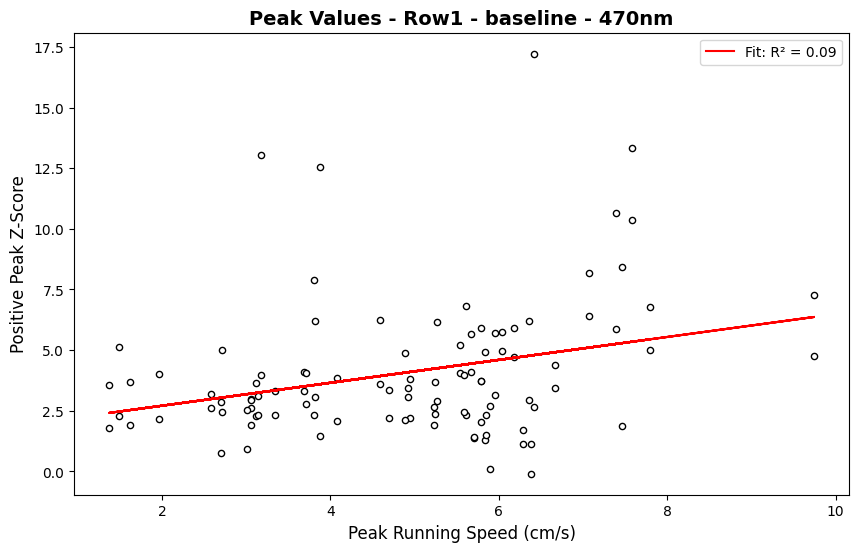

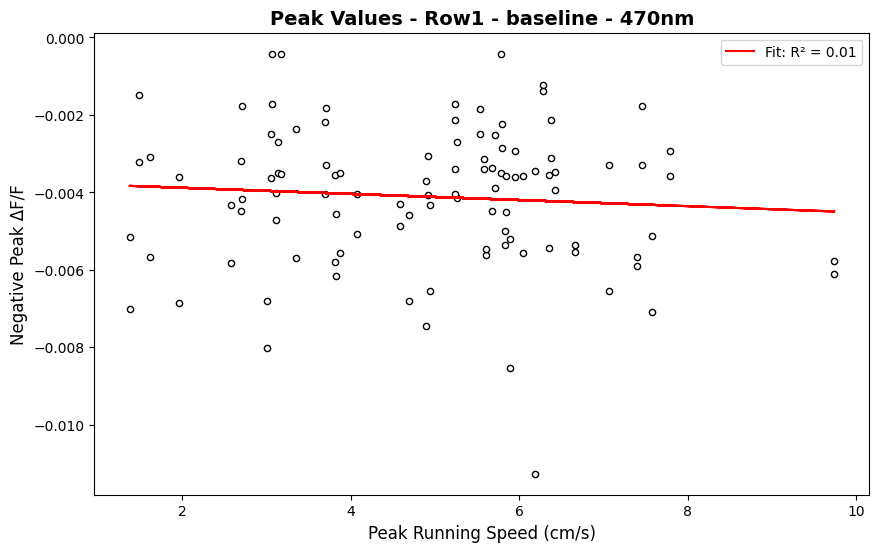

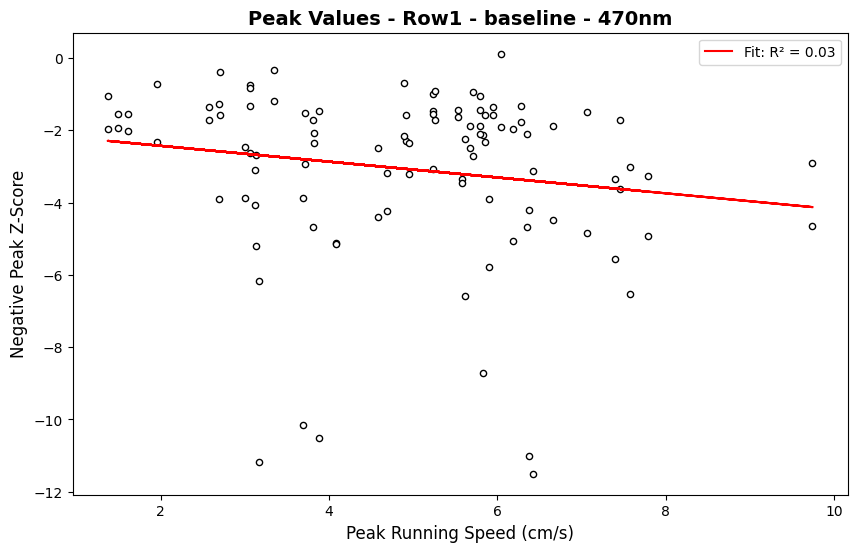

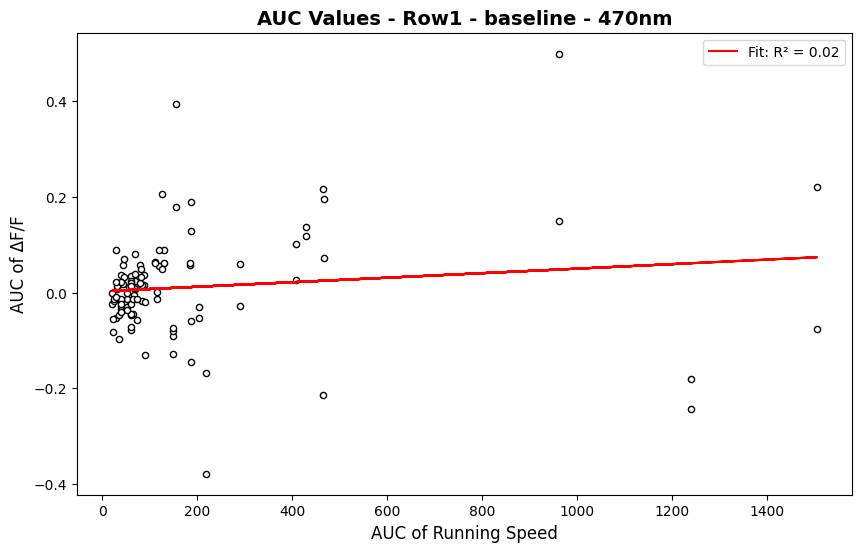

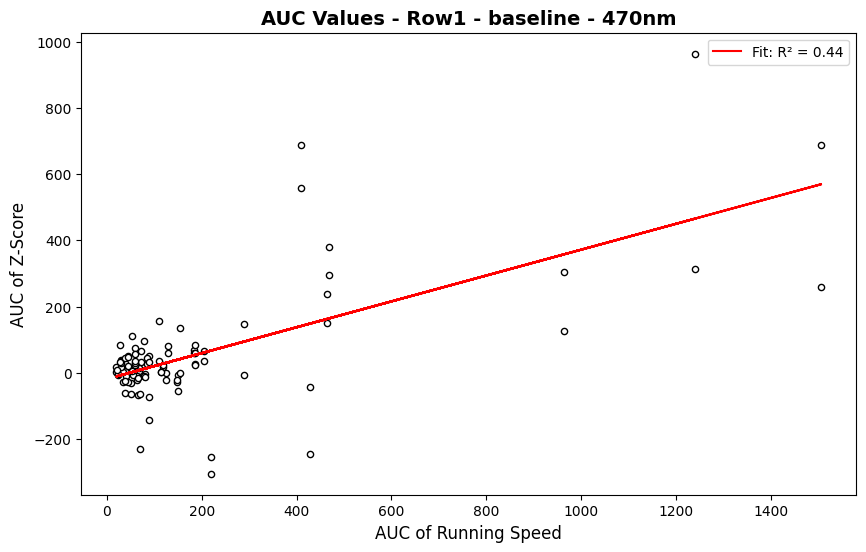

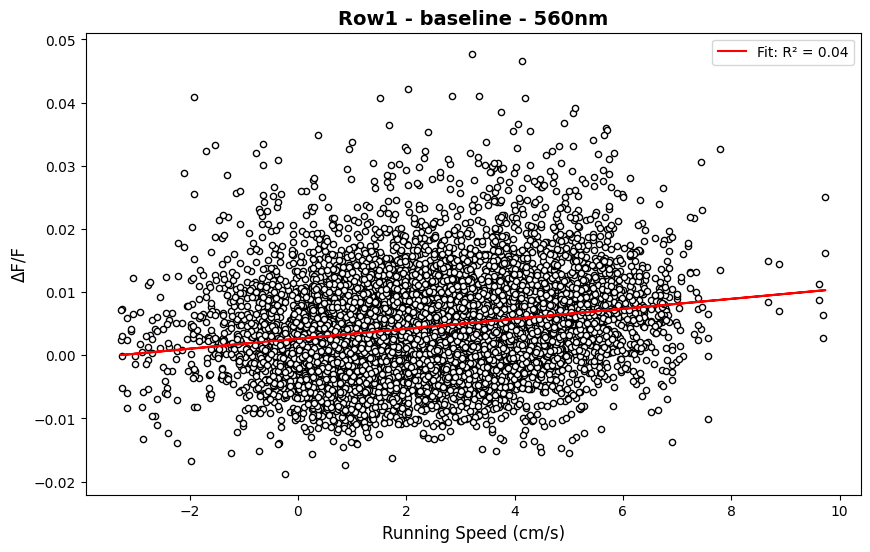

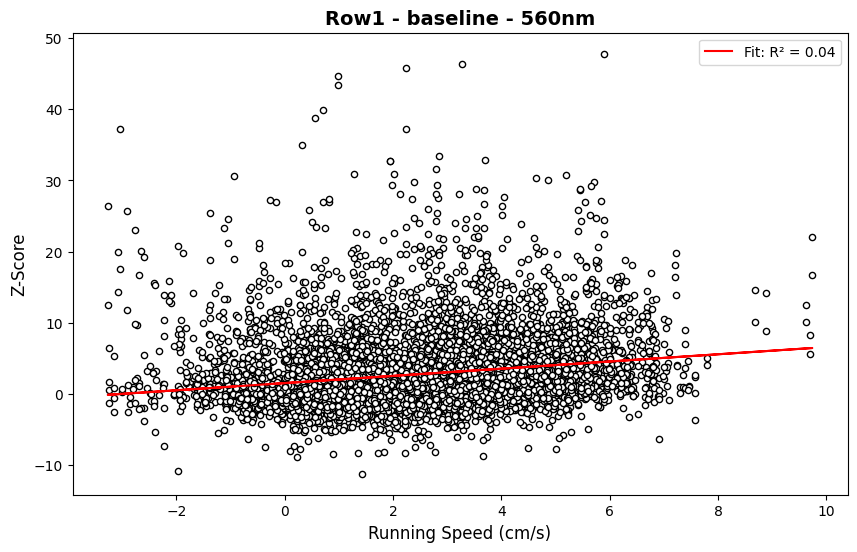

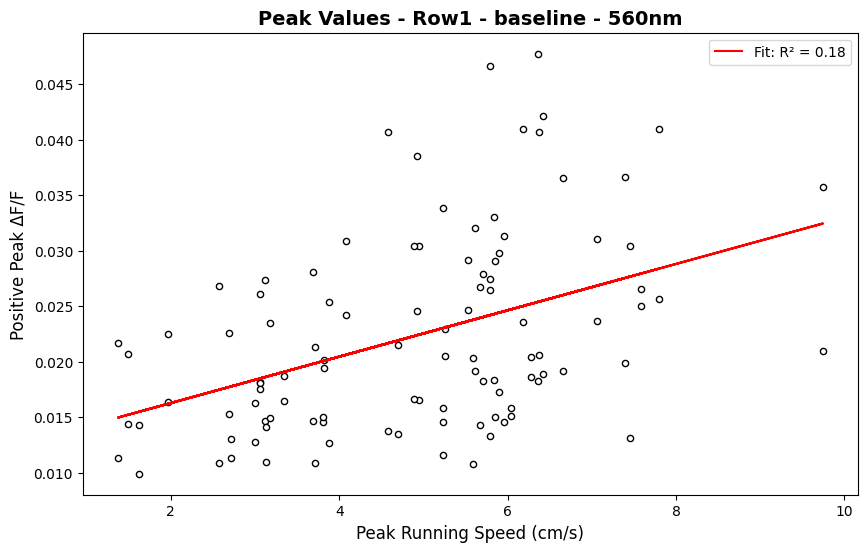

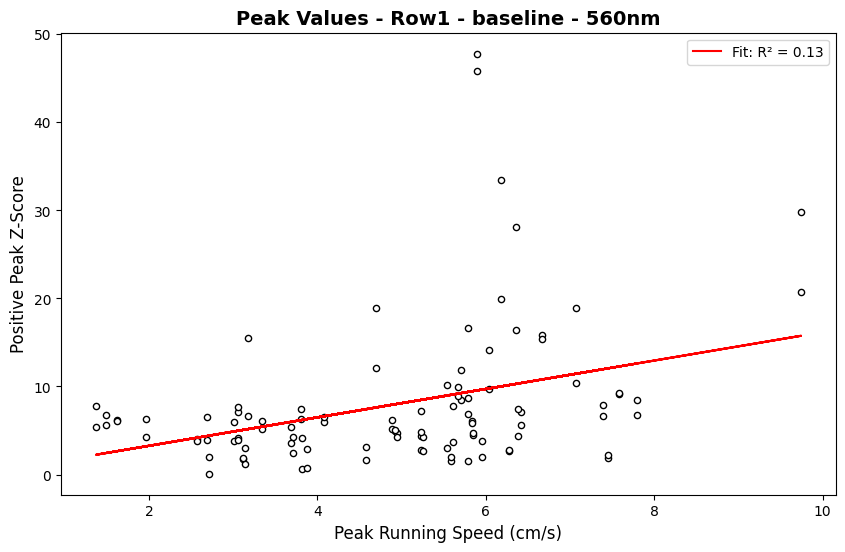

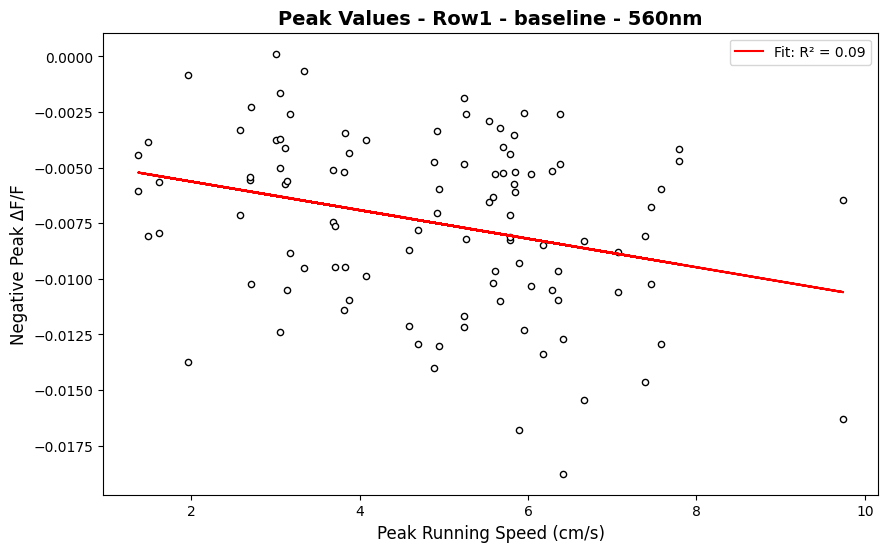

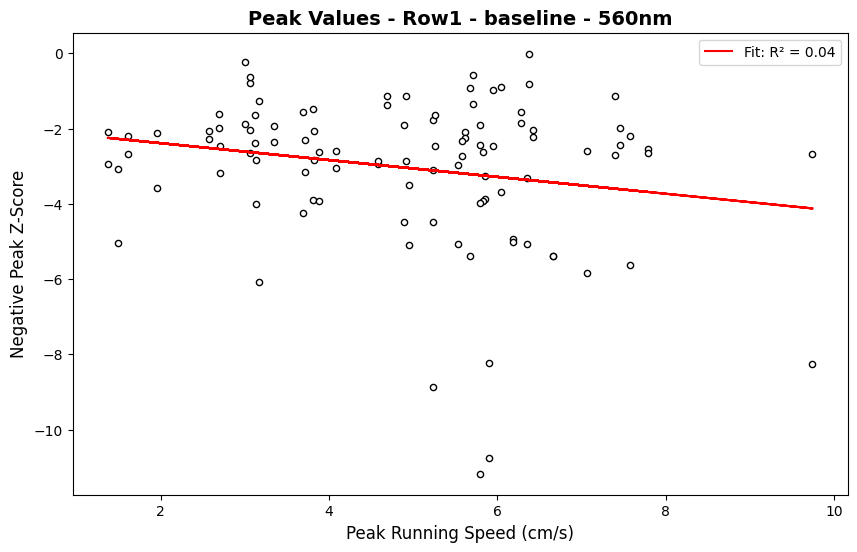

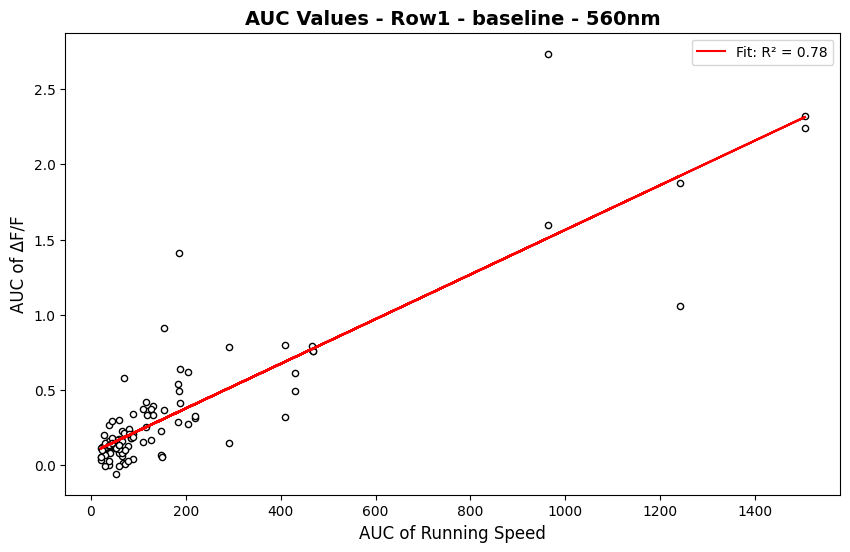

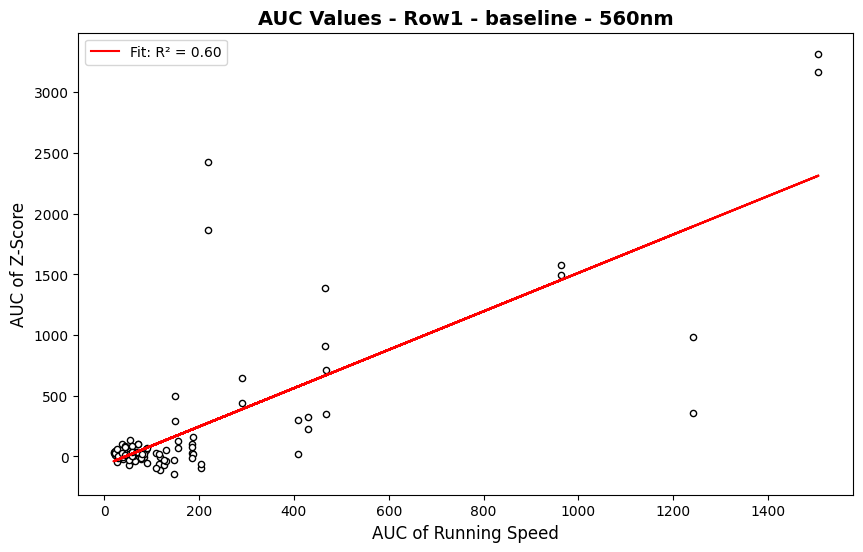

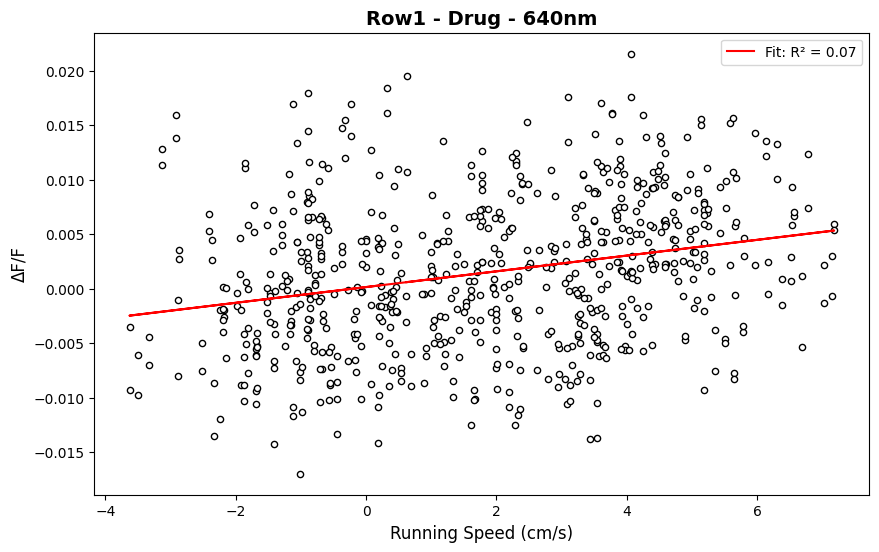

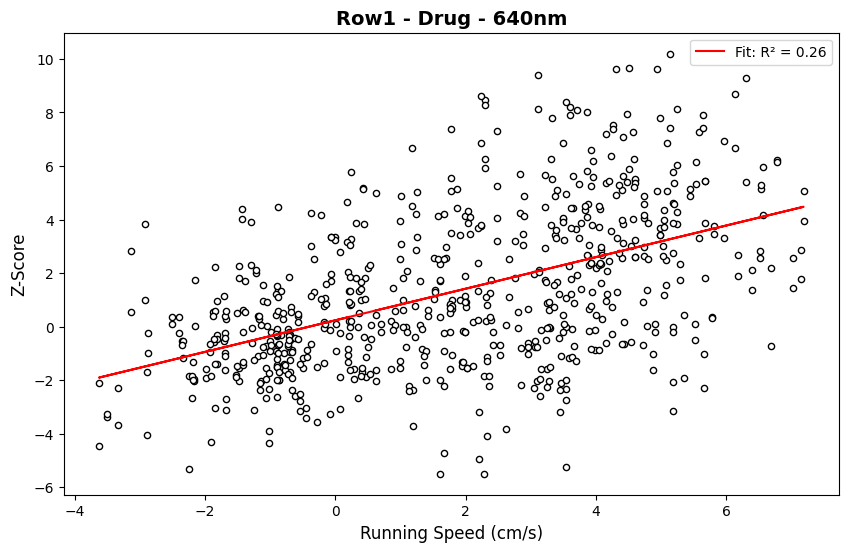

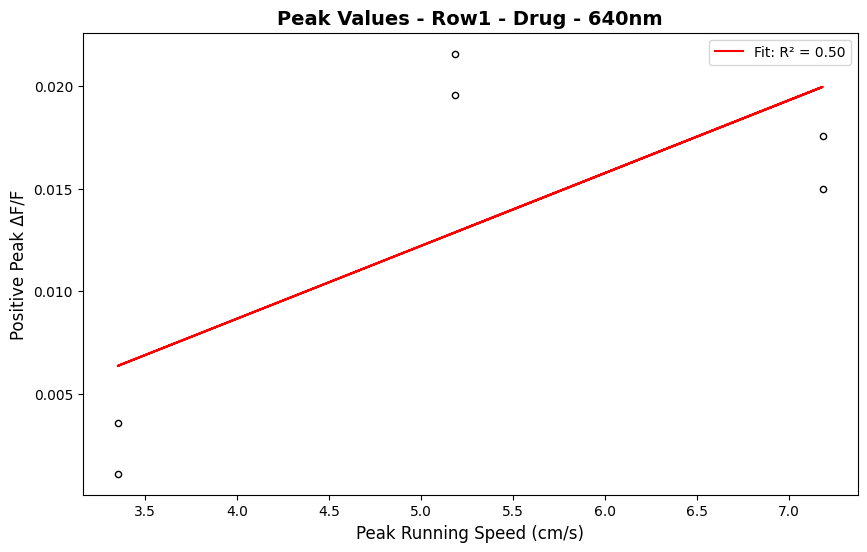

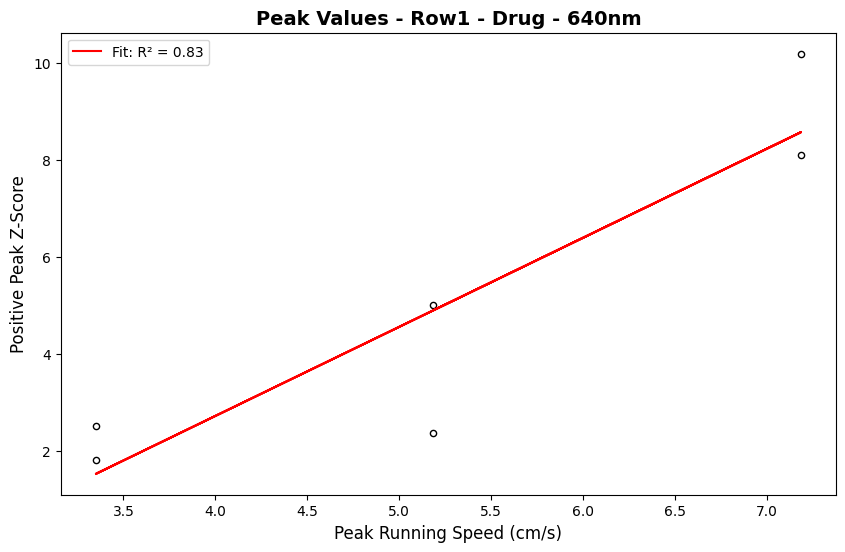

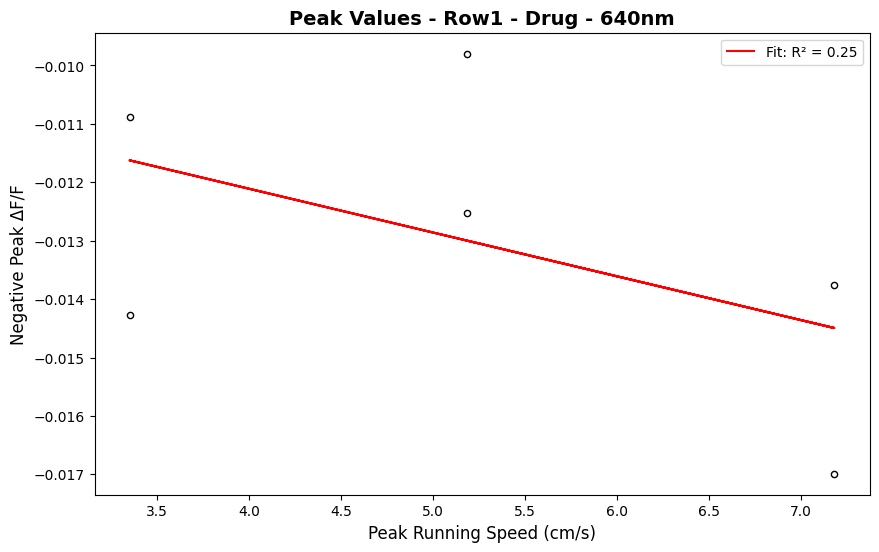

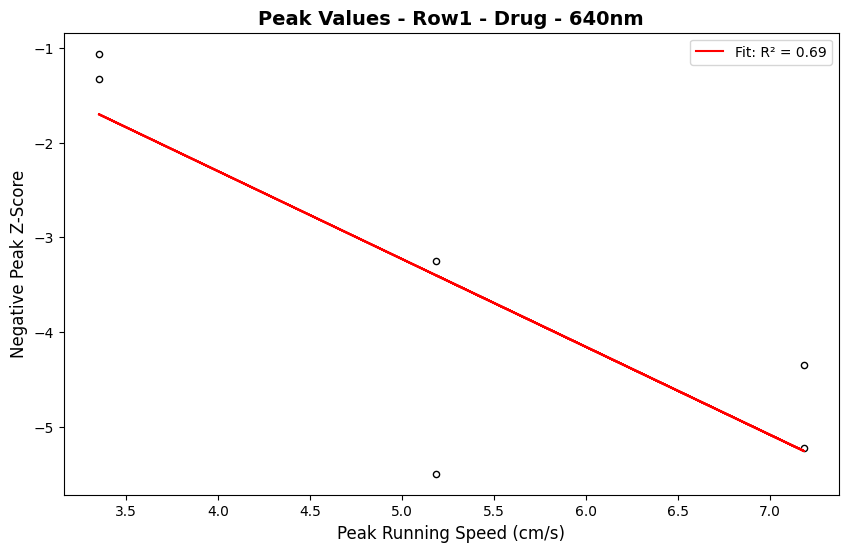

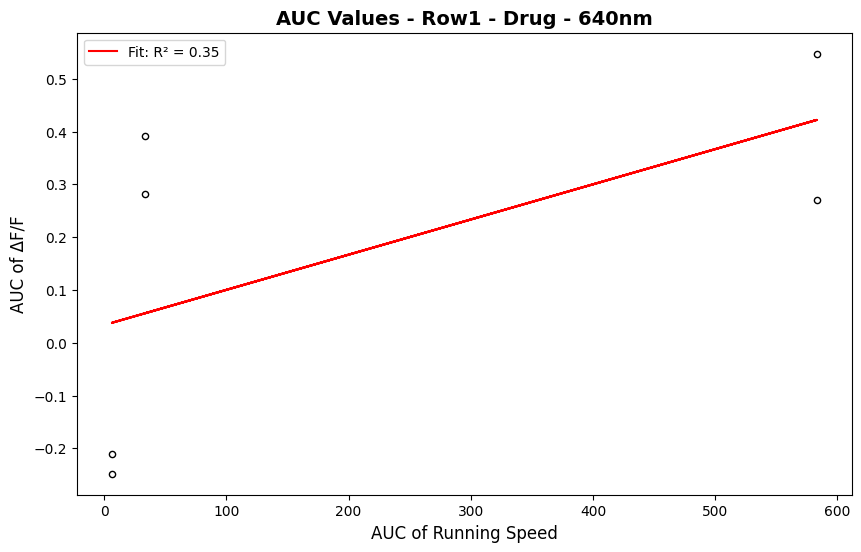

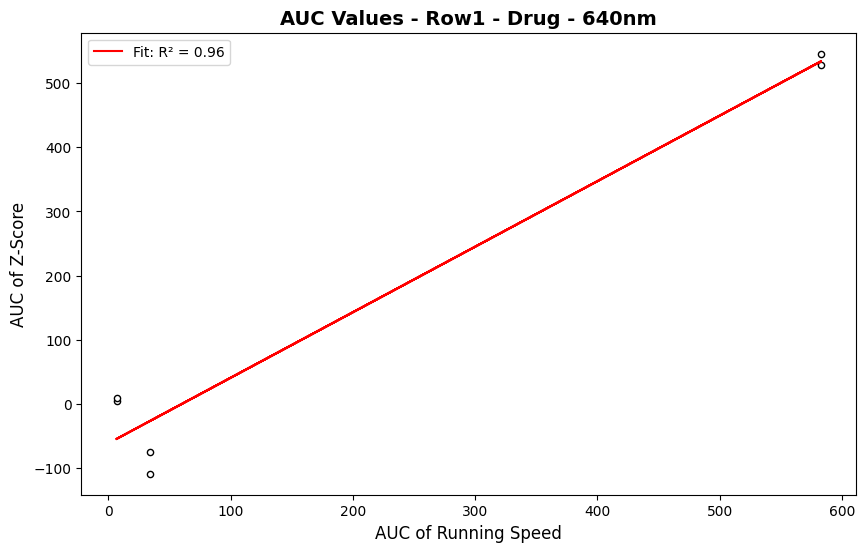

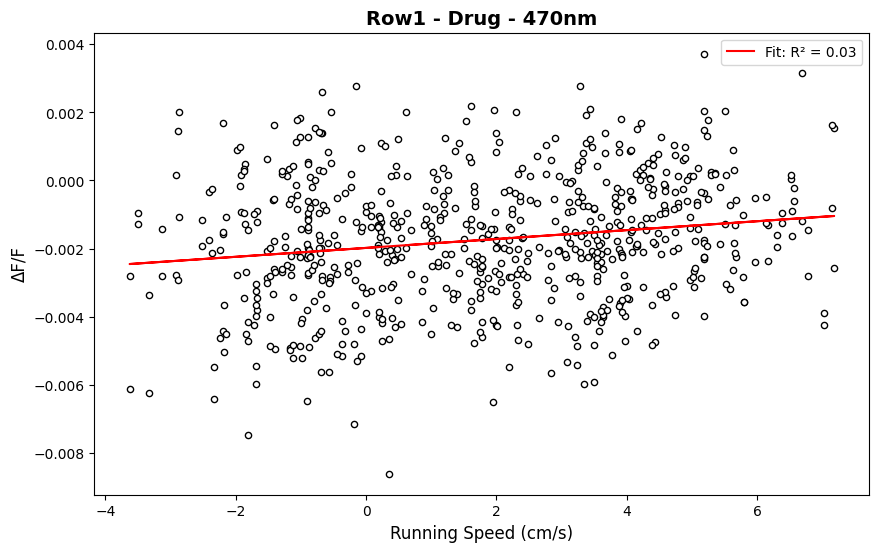

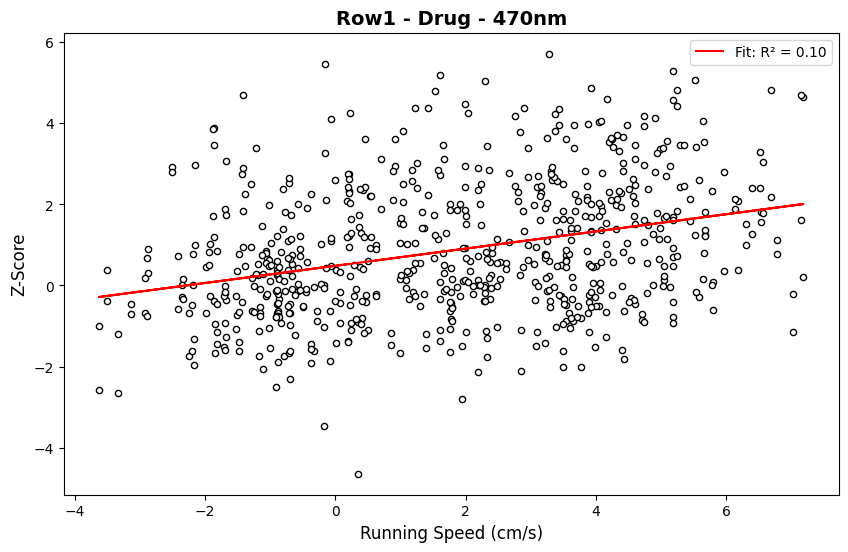

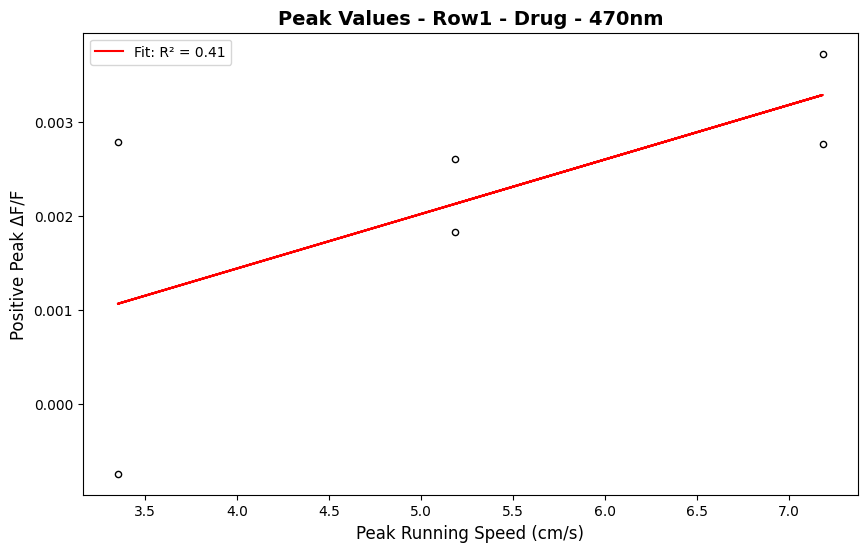

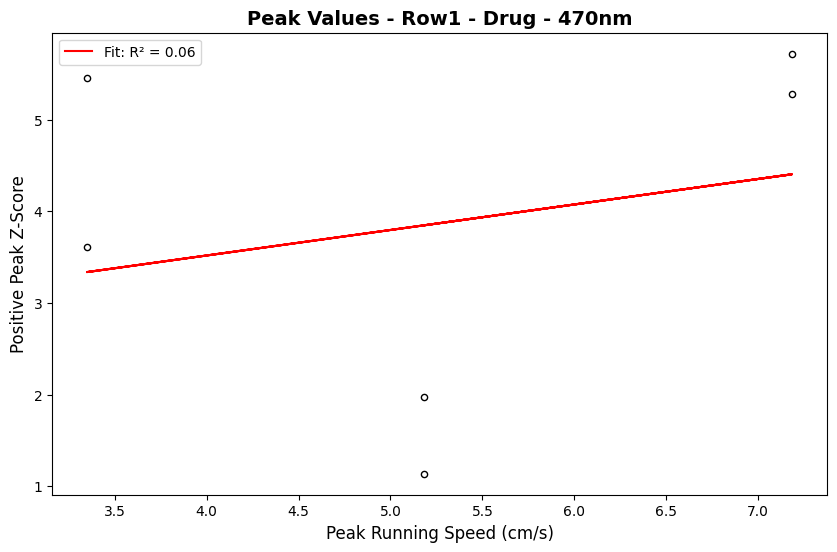

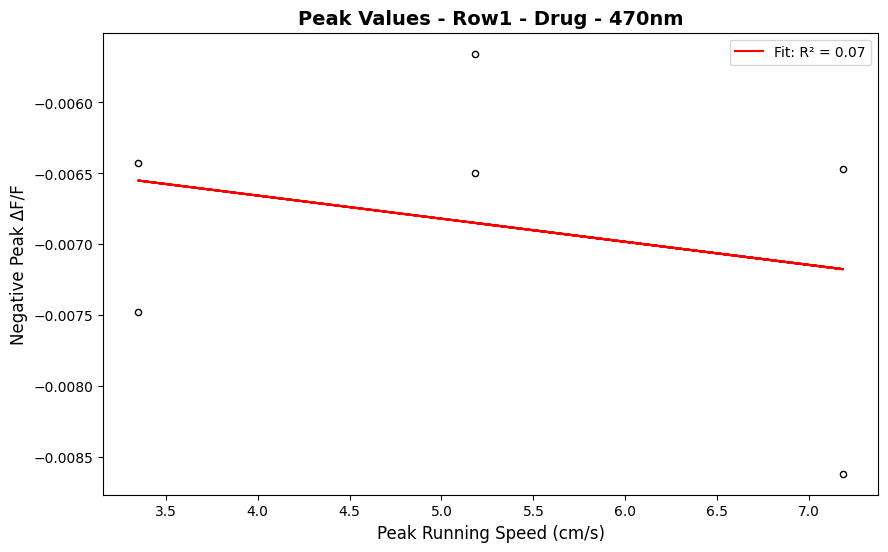

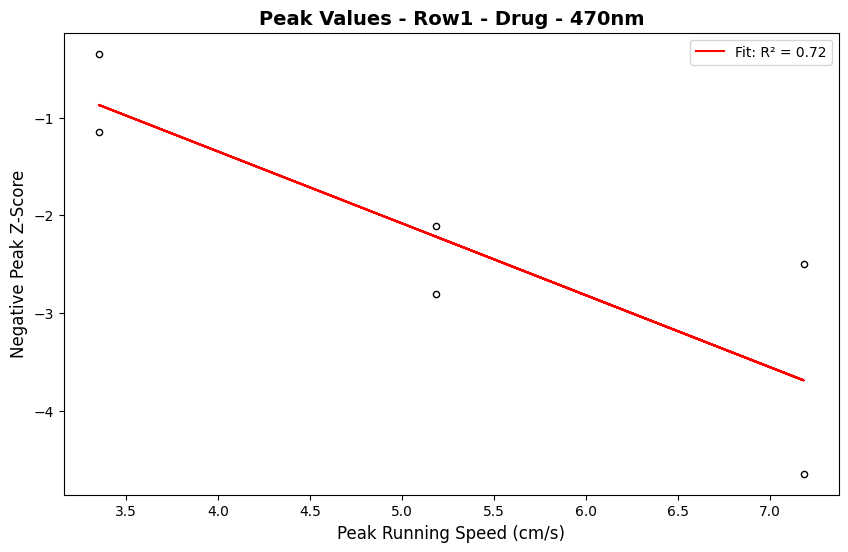

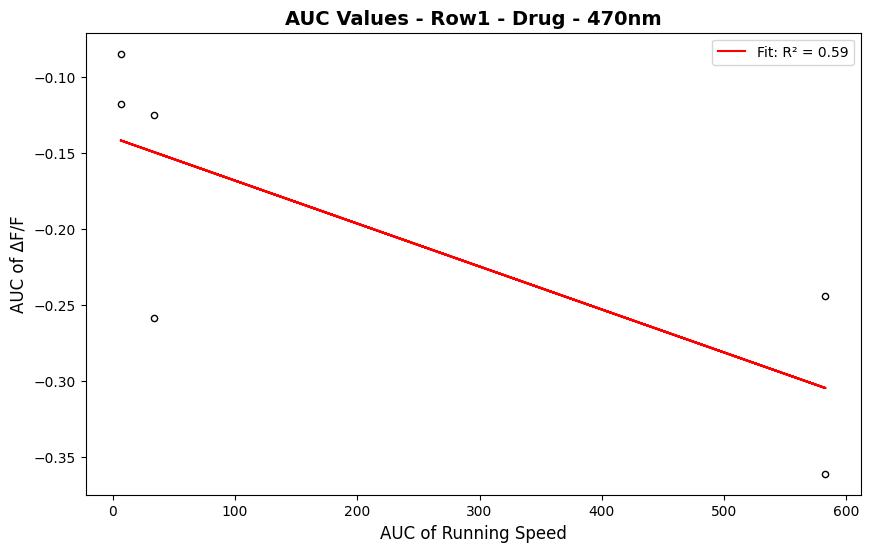

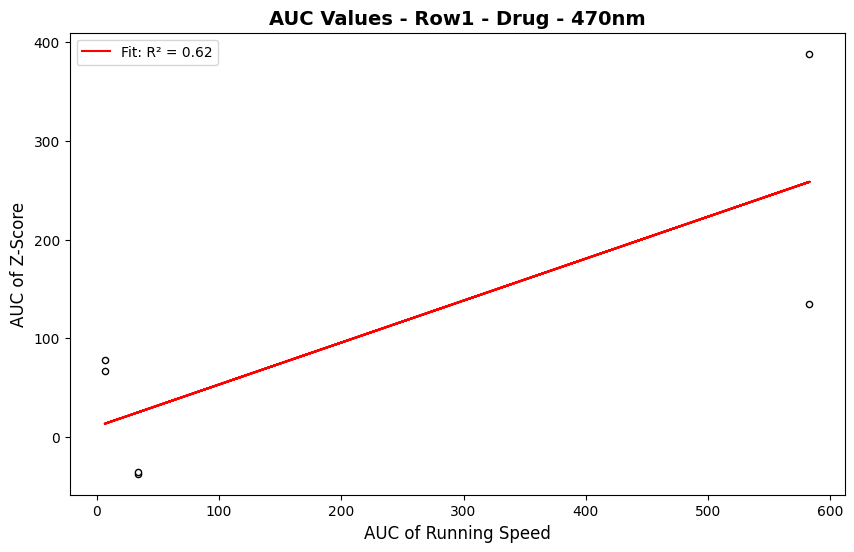

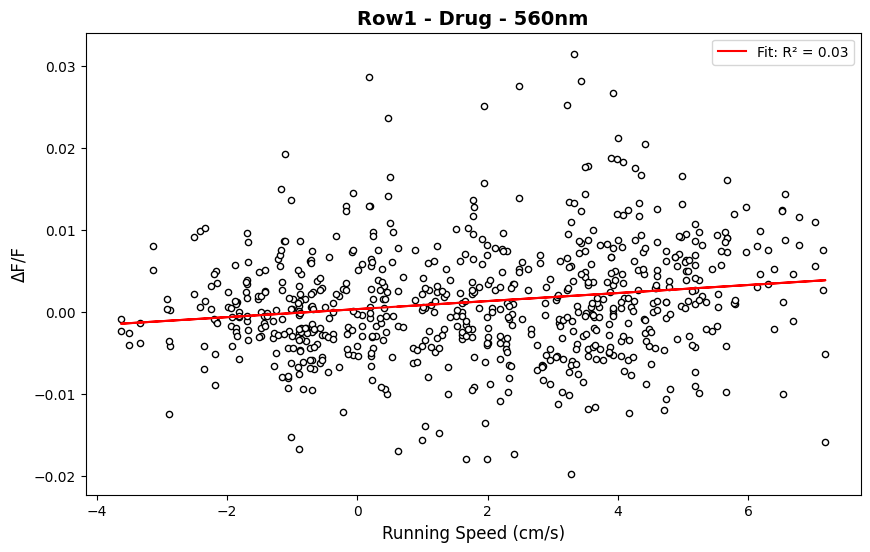

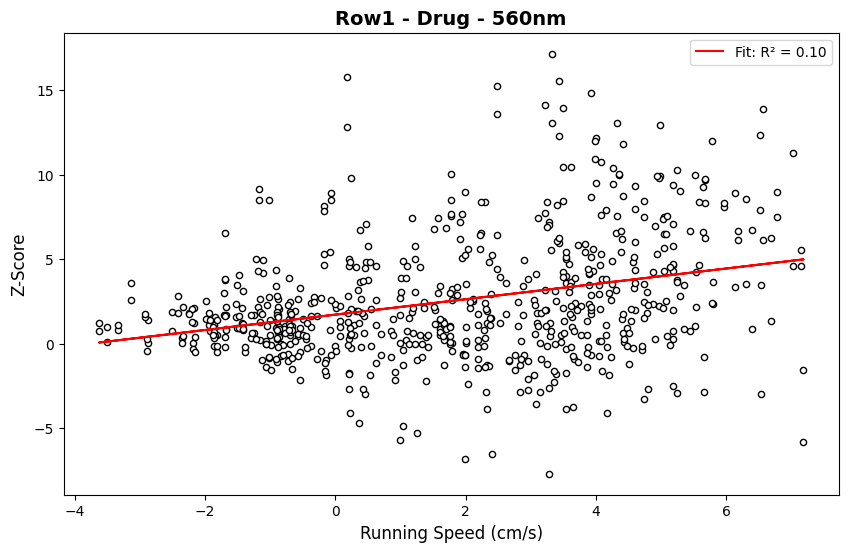

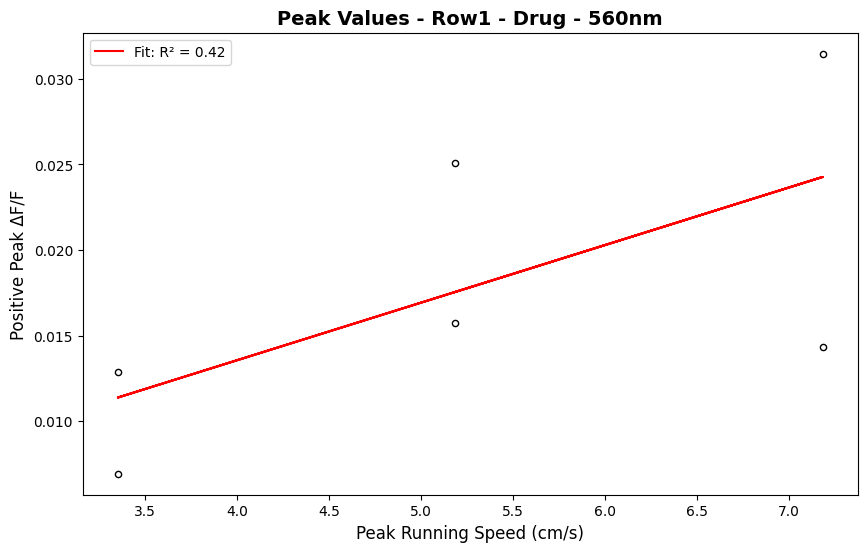

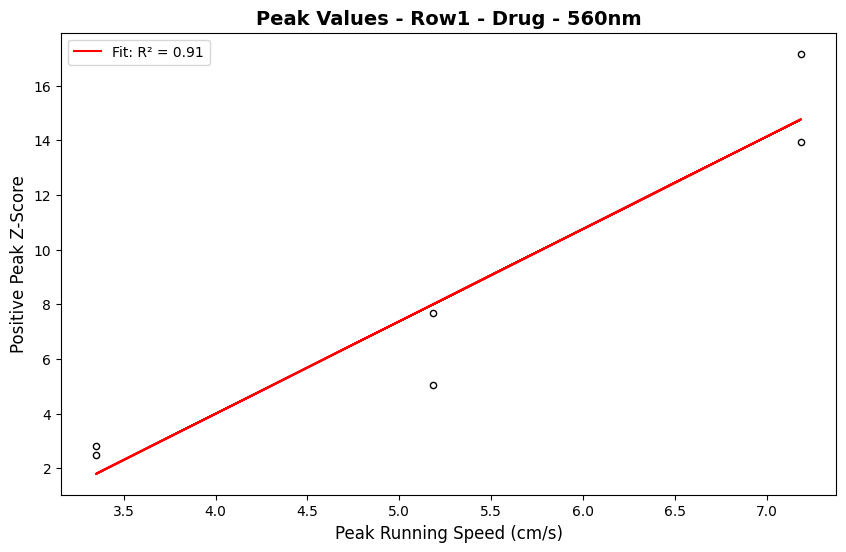

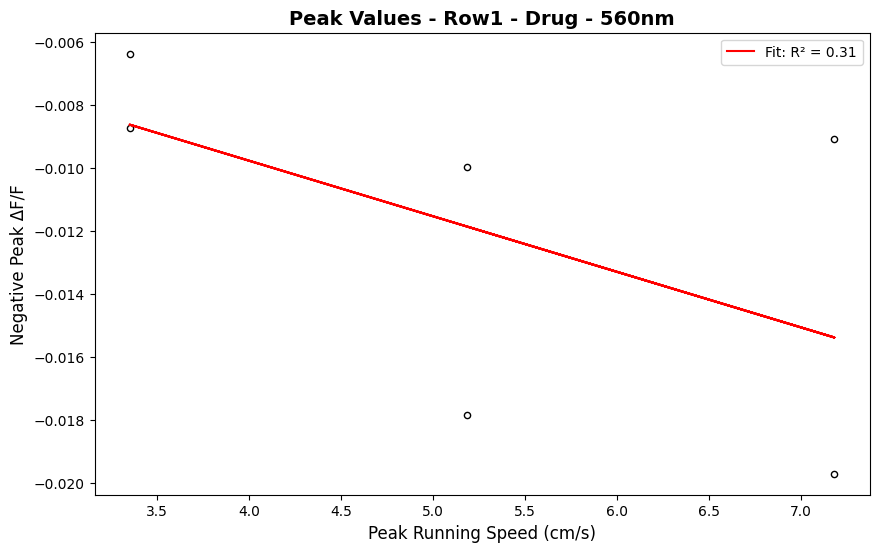

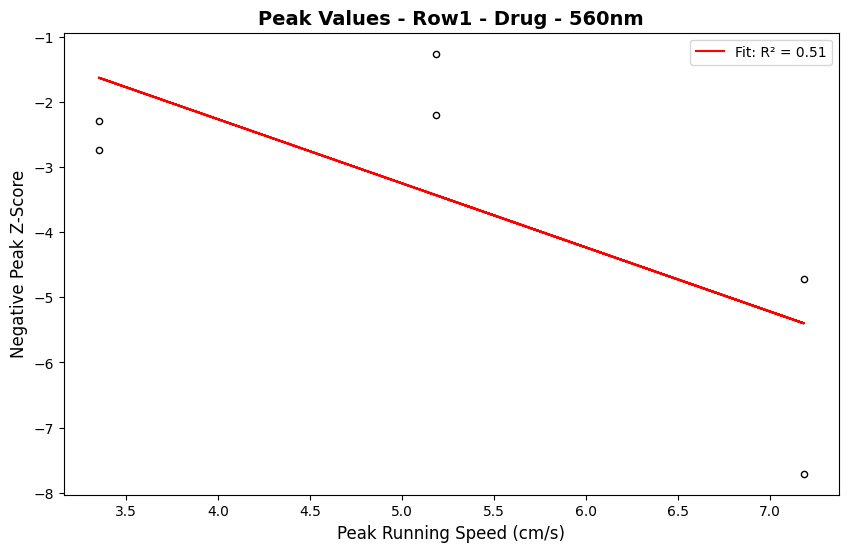

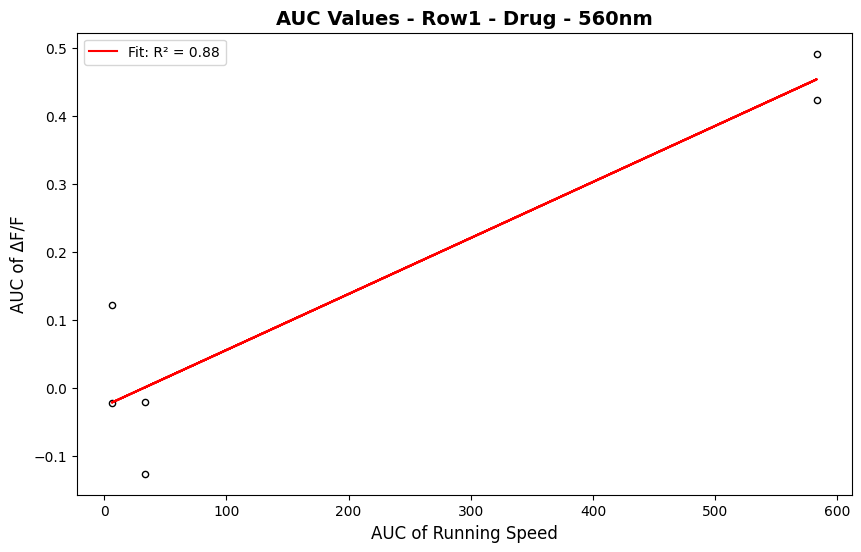

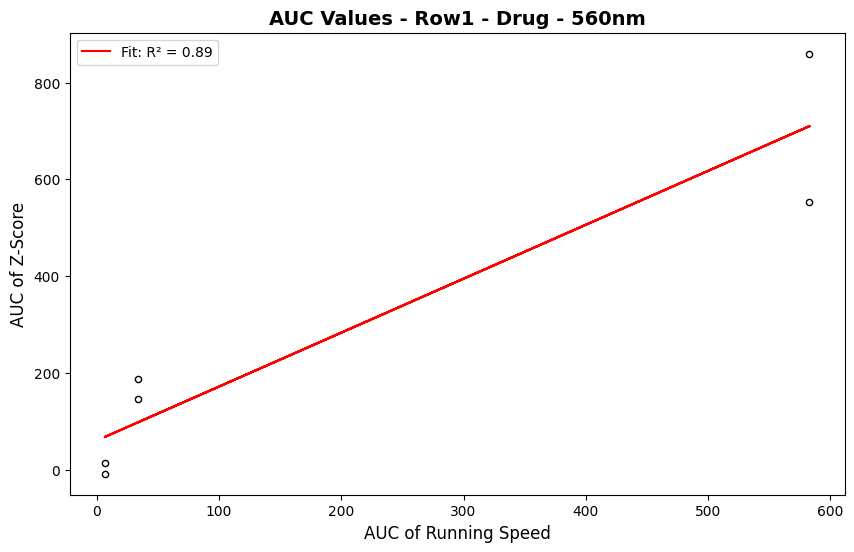

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

bout_analysis_results_directory = r"C:\Users\Pulee\Desktop\Bout analysis\running+drug\running_drug_bout_analysis_results_20260424_211319.pickle"
with open(bout_analysis_results_directory, "rb") as f:
    bout_analysis_results = pickle.load(f)
    
all_results = []
all_row_names = set()
all_categories = set()
all_wavelengths = set()
for row_name, animals in bout_analysis_results.items():
    all_row_names.add(row_name)
    for category, cat_results in animals.items():
        all_categories.add(category)
        for res in cat_results:
            bout_speeds = res["bout_speeds"]
            bout_dffs = res["bout_dffs"]
            speed_timestamps = res["speed_timestamps"]
            event_fiber_timestamps = res["fiber_timestamps"]
            # Interpolate dff to match speed timestamps
            bout_speeds_interp = np.interp(event_fiber_timestamps, speed_timestamps, bout_speeds)
            for wavelength, dff in bout_dffs.items():
                all_wavelengths.add(wavelength)
                zscore = res["bout_zscores"][wavelength]
                results = {
                    "row_name": row_name,
                    "category": category,
                    "wavelength": wavelength,
                    "speeds": bout_speeds_interp,
                    "dff": dff,
                    "zscore": zscore
                }
                all_results.append(results)

for row_name in all_row_names:
    for category in all_categories:
        for wavelength in all_wavelengths:
            target_results = [res for res in all_results if res["row_name"] == row_name and res["category"] == category and res["wavelength"] == wavelength]
            if not target_results:
                continue
            speeds = np.concatenate([res["speeds"] for res in target_results])
            dffs = np.concatenate([res["dff"] for res in target_results])
            zscores = np.concatenate([res["zscore"] for res in target_results])
            r_squared_dff = np.corrcoef(speeds, dffs)[0, 1] ** 2
            fitted_line_dff = np.polyfit(speeds, dffs, 1)
            r_squared_zscore = np.corrcoef(speeds, zscores)[0, 1] ** 2
            fitted_line_zscore = np.polyfit(speeds, zscores, 1)
            plt.figure(figsize=(6, 6))
            plt.scatter(speeds, dffs, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
            plt.plot(speeds, np.polyval(fitted_line_dff, speeds), label=f"Fit: R² = {r_squared_dff:.2f}", color='red')
            plt.title(f"{row_name} - {category} - {wavelength}nm", fontweight='bold', fontsize=14)
            plt.xlabel("Running Speed (cm/s)", fontsize=12)
            plt.ylabel("ΔF/F", fontsize=12)
            plt.legend()
            plt.show()
            
            plt.figure(figsize=(6, 6))
            plt.scatter(speeds, zscores, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
            plt.plot(speeds, np.polyval(fitted_line_zscore, speeds), label=f"Fit: R² = {r_squared_zscore:.2f}", color='red')
            plt.title(f"{row_name} - {category} - {wavelength}nm", fontweight='bold', fontsize=14)
            plt.xlabel("Running Speed (cm/s)", fontsize=12)
            plt.ylabel("Z-Score", fontsize=12)
            plt.legend()
            plt.show()
            
            peak_speeds = [np.max(res["speeds"]) for res in target_results]
            positive_peak_dffs = [np.max(res["dff"]) for res in target_results]
            negative_peak_dffs = [np.min(res["dff"]) for res in target_results]
            positive_peak_zscores = [np.max(res["zscore"]) for res in target_results]
            negative_peak_zscores = [np.min(res["zscore"]) for res in target_results]
            
            r_squared_positive_peak_dff = np.corrcoef(peak_speeds, positive_peak_dffs)[0, 1] ** 2
            fitted_line_positive_peak_dff = np.polyfit(peak_speeds, positive_peak_dffs, 1)
            r_squared_positive_peak_zscore = np.corrcoef(peak_speeds, positive_peak_zscores)[0, 1] ** 2
            fitted_line_positive_peak_zscore = np.polyfit(peak_speeds, positive_peak_zscores, 1)
            
            r_squared_negative_peak_dff = np.corrcoef(peak_speeds, negative_peak_dffs)[0, 1] ** 2
            fitted_line_negative_peak_dff = np.polyfit(peak_speeds, negative_peak_dffs, 1)
            r_squared_negative_peak_zscore = np.corrcoef(peak_speeds, negative_peak_zscores)[0, 1] ** 2
            fitted_line_negative_peak_zscore = np.polyfit(peak_speeds, negative_peak_zscores, 1)

            plt.figure(figsize=(6, 6))
            plt.scatter(peak_speeds, positive_peak_dffs, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
            plt.plot(peak_speeds, np.polyval(fitted_line_positive_peak_dff, peak_speeds), label=f"Fit: R² = {r_squared_positive_peak_dff:.2f}", color='red')
            plt.title(f"Peak Values - {row_name} - {category} - {wavelength}nm", fontweight='bold', fontsize=14)
            plt.xlabel("Peak Running Speed (cm/s)", fontsize=12)
            plt.ylabel("Positive Peak ΔF/F", fontsize=12)
            plt.legend()
            plt.show()
            
            plt.figure(figsize=(6, 6))
            plt.scatter(peak_speeds, positive_peak_zscores, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
            plt.plot(peak_speeds, np.polyval(fitted_line_positive_peak_zscore, peak_speeds), label=f"Fit: R² = {r_squared_positive_peak_zscore:.2f}", color='red')
            plt.title(f"Peak Values - {row_name} - {category} - {wavelength}nm", fontweight='bold', fontsize=14)
            plt.xlabel("Peak Running Speed (cm/s)", fontsize=12)
            plt.ylabel("Positive Peak Z-Score", fontsize=12)
            plt.legend()
            plt.show()
            
            plt.figure(figsize=(6, 6))
            plt.scatter(peak_speeds, negative_peak_dffs, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
            plt.plot(peak_speeds, np.polyval(fitted_line_negative_peak_dff, peak_speeds), label=f"Fit: R² = {r_squared_negative_peak_dff:.2f}", color='red')
            plt.title(f"Peak Values - {row_name} - {category} - {wavelength}nm", fontweight='bold', fontsize=14)
            plt.xlabel("Peak Running Speed (cm/s)", fontsize=12)
            plt.ylabel("Negative Peak ΔF/F", fontsize=12)
            plt.legend()
            plt.show()
            
            plt.figure(figsize=(6, 6))
            plt.scatter(peak_speeds, negative_peak_zscores, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
            plt.plot(peak_speeds, np.polyval(fitted_line_negative_peak_zscore, peak_speeds), label=f"Fit: R² = {r_squared_negative_peak_zscore:.2f}", color='red')
            plt.title(f"Peak Values - {row_name} - {category} - {wavelength}nm", fontweight='bold', fontsize=14)
            plt.xlabel("Peak Running Speed (cm/s)", fontsize=12)
            plt.ylabel("Negative Peak Z-Score", fontsize=12)
            plt.legend()
            plt.show()
            
            auc_speeds = [np.trapz(res["speeds"], dx=1) for res in target_results]
            auc_dffs = [np.trapz(res["dff"], dx=1) for res in target_results]
            auc_zscores = [np.trapz(res["zscore"], dx=1) for res in target_results]
            r_squared_auc_dff = np.corrcoef(auc_speeds, auc_dffs)[0, 1] ** 2
            fitted_line_auc_dff = np.polyfit(auc_speeds, auc_dffs, 1)
            r_squared_auc_zscore = np.corrcoef(auc_speeds, auc_zscores)[0, 1] ** 2
            fitted_line_auc_zscore = np.polyfit(auc_speeds, auc_zscores, 1)
            
            plt.figure(figsize=(6, 6))
            plt.scatter(auc_speeds, auc_dffs, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
            plt.plot(auc_speeds, np.polyval(fitted_line_auc_dff, auc_speeds), label=f"Fit: R² = {r_squared_auc_dff:.2f}", color='red')
            plt.title(f"AUC Values - {row_name} - {category} - {wavelength}nm", fontweight='bold', fontsize=14)
            plt.xlabel("AUC of Running Speed", fontsize=12)
            plt.ylabel("AUC of ΔF/F", fontsize=12)
            plt.legend()
            plt.show()
            
            plt.figure(figsize=(6, 6))
            plt.scatter(auc_speeds, auc_zscores, color="#FFFFFF", alpha=1, edgecolors='#000000', s=20)
            plt.plot(auc_speeds, np.polyval(fitted_line_auc_zscore, auc_speeds), label=f"Fit: R² = {r_squared_auc_zscore:.2f}", color='red')
            plt.title(f"AUC Values - {row_name} - {category} - {wavelength}nm", fontweight='bold', fontsize=14)
            plt.xlabel("AUC of Running Speed", fontsize=12)
            plt.ylabel("AUC of Z-Score", fontsize=12)
            plt.legend()
            plt.show()